<a href="https://colab.research.google.com/github/rodrigoviannasn/MAT-422/blob/main/MAT422_HW_1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT 422 — Homework 1.3: QR Decomposition and Least Squares
Rodrigo Vianna | 9/6/2026

In [39]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.3.1 QR Decomposition
QR decomposition factors a matrix A into two matrices:

$$
A=QR,
$$

where Q has orthonormal columns and R is an upper-triangular matrix. A matrix with orthonormal columns satisfies

$$
Q^TQ=I.
$$

In this example, I decompose a $3 \times 2$ matrix and verify both properties.


In [40]:
A_qr = np.array([
    [2.0, 1.0],
    [1.0, 3.0],
    [2.0, 2.0]
])

Q, R = np.linalg.qr(A_qr, mode="reduced")

print("Original matrix A:")
print(A_qr)

print("\nMatrix Q:")
print(Q)

print("\nMatrix R:")
print(R)

print("\nVerify Q^T Q:")
print(Q.T @ Q)

print("\nIs Q^T Q approximately the identity matrix?")
print(np.allclose(Q.T @ Q, np.eye(Q.shape[1])))

print("\nReconstructed matrix QR:")
print(Q @ R)

print("\nDoes QR equal A?")
print(np.allclose(Q @ R, A_qr))

print("\nIs R upper triangular?")
print(np.allclose(R, np.triu(R)))

Original matrix A:
[[2. 1.]
 [1. 3.]
 [2. 2.]]

Matrix Q:
[[-0.6667  0.4472]
 [-0.3333 -0.8944]
 [-0.6667  0.    ]]

Matrix R:
[[-3.     -3.    ]
 [ 0.     -2.2361]]

Verify Q^T Q:
[[ 1. -0.]
 [-0.  1.]]

Is Q^T Q approximately the identity matrix?
True

Reconstructed matrix QR:
[[2. 1.]
 [1. 3.]
 [2. 2.]]

Does QR equal A?
True

Is R upper triangular?
True


The results confirm that Q^TQ is approximately the identity matrix, so the columns of Q are orthonormal. The matrix R is upper triangular, and multiplying Q by R reconstructs the original matrix A. Therefore, this is a valid QR decomposition.

### Section Conclusion
The QR decomposition separated the original matrix into an orthonormal matrix Q and an upper-triangular matrix R. The checks showed that Q^TQ is approximately the identity matrix and that QR reconstructs the original matrix, thus confirming that the decomposition works.


## 1.3.2 Least-Squares Problems


A least-squares problem occurs when a system has more equations than unknowns, so an exact solution may not exist.

The goal is to find $\hat{x}\$ that minimizes the squared residual:

$$
\min_x \|Ax-b\|_2^2.
$$

The residual vector is: $
 r=b-A\hat{x}.
$

For a least-squares solution, the residual is orthogonal to every column of A. This can be verified by checking that $A^Tr$ is approximately zero.

In [41]:
# An overdetermined system: 4 equations and 2 unknowns
A_ls = np.array([
    [1.0, 1.0],
    [1.0, 2.0],
    [1.0, 4.0],
    [1.0, 5.0]
])

b_ls = np.array([2.0, 3.0, 6.0, 7.0])

# Solve the least-squares problem using QR decomposition
Q_ls, R_ls = np.linalg.qr(A_ls, mode="reduced")
x_hat = np.linalg.solve(R_ls, Q_ls.T @ b_ls)

# Predicted values and residual
predicted_b = A_ls @ x_hat
residual = b_ls - predicted_b

print("Matrix A:")
print(A_ls)

print("\nVector b:")
print(b_ls)

print("\nLeast-squares solution x_hat:")
print(x_hat)

print("\nPredicted values A @ x_hat:")
print(predicted_b)

print("\nResidual vector r = b - A @ x_hat:")
print(residual)

print("\nResidual norm ||r||:")
print(np.linalg.norm(residual))

print("\nVerify A^T @ r:")
print(A_ls.T @ residual)

print("\nIs A^T @ r approximately zero?")
print(np.allclose(A_ls.T @ residual, np.zeros(A_ls.shape[1])))

Matrix A:
[[1. 1.]
 [1. 2.]
 [1. 4.]
 [1. 5.]]

Vector b:
[2. 3. 6. 7.]

Least-squares solution x_hat:
[0.6 1.3]

Predicted values A @ x_hat:
[1.9 3.2 5.8 7.1]

Residual vector r = b - A @ x_hat:
[ 0.1 -0.2  0.2 -0.1]

Residual norm ||r||:
0.31622776601683783

Verify A^T @ r:
[-0.  0.]

Is A^T @ r approximately zero?
True


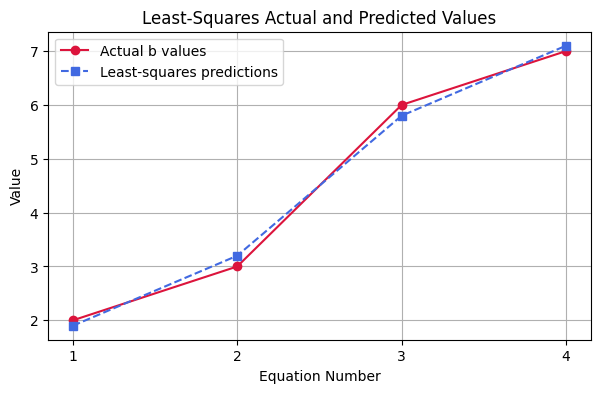

In [42]:
equation_number = np.arange(1, len(b_ls) + 1)

plt.figure(figsize=(7, 4))
plt.plot(equation_number, b_ls, "o-", color="crimson", label="Actual b values")
plt.plot(equation_number, predicted_b, "s--", color="royalblue",
         label="Least-squares predictions")

plt.xlabel("Equation Number")
plt.ylabel("Value")
plt.title("Least-Squares Actual and Predicted Values")
plt.xticks(equation_number)
plt.grid()
plt.legend()
plt.show()

The system has more equations than unknowns, so the least-squares solution finds the vector $\hat{x}$ that makes $A\hat{x}$ as close as possible to b. The residual is not exactly zero, meaning the system does not fit perfectly. However, $A^Tr$ is approximately zero, which confirms that the residual is orthogonal to the column space of A. The QR decomposition from the previous section was used to calculate the solution.

### Section Conclusion

The least-squares method produced a solution that makes $A\hat{x}$ as close as possible to b, even though the system does not have an exact solution. The residual was not zero, but $A^Tr$ was approximately zero. Therefore the residual is orthogonal to the column space of A, which is a property of least-squares solutions.


## 1.3.3 Linear Regression





Linear regression models the relationship between an input variable x and an output variable y with a line:

$$
\hat{y}=\beta_0+\beta_1x.
$$

In this illustrative dataset, x represents practice hours and y represents a quiz score. I use least squares to find the intercept $\beta_0$ and slope $\beta_1$ that create the best-fit line.

In [43]:
# Illustrative practice-hours and quiz-score data
hours = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
scores = np.array([51, 55, 61, 64, 70, 72, 78, 83], dtype=float)

# Build the design matrix: first column is for the intercept
A_reg = np.column_stack((np.ones_like(hours), hours))

# Solve with QR decomposition
Q_reg, R_reg = np.linalg.qr(A_reg, mode="reduced")
beta = np.linalg.solve(R_reg, Q_reg.T @ scores)

intercept, slope = beta
predicted_scores = A_reg @ beta
residuals = scores - predicted_scores

# Calculate R-squared
sum_squared_errors = np.sum(residuals**2)
total_sum_squares = np.sum((scores - np.mean(scores))**2)
r_squared = 1 - sum_squared_errors / total_sum_squares

print(f"Intercept (β₀): {intercept:.4f}")
print(f"Slope (β₁): {slope:.4f}")
print(f"Regression equation: score = {intercept:.4f} + {slope:.4f}(hours)")
print(f"R² value: {r_squared:.4f}")

print("\nResiduals:")
print(residuals)

Intercept (β₀): 46.5000
Slope (β₁): 4.5000
Regression equation: score = 46.5000 + 4.5000(hours)
R² value: 0.9942

Residuals:
[ 0.  -0.5  1.  -0.5  1.  -1.5  0.   0.5]


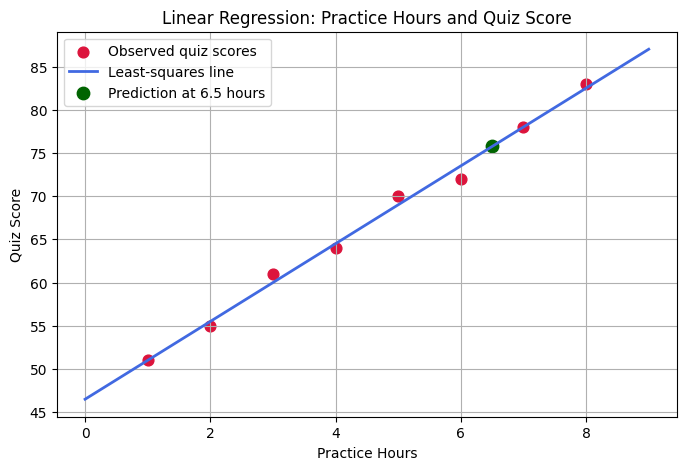

Predicted score for 6.5 practice hours: 75.75


In [44]:
x_line = np.linspace(0, 9, 100)
y_line = intercept + slope * x_line

# Example prediction
new_hours = 6.5
predicted_new_score = intercept + slope * new_hours

plt.figure(figsize=(8, 5))
plt.scatter(hours, scores, color="crimson", s=60, label="Observed quiz scores")
plt.plot(x_line, y_line, color="royalblue", linewidth=2, label="Least-squares line")

plt.scatter(new_hours, predicted_new_score, color="darkgreen", s=80,
            label=f"Prediction at {new_hours} hours")

plt.xlabel("Practice Hours")
plt.ylabel("Quiz Score")
plt.title("Linear Regression: Practice Hours and Quiz Score")
plt.grid()
plt.legend()
plt.show()

print(f"Predicted score for {new_hours} practice hours: {predicted_new_score:.2f}")

The regression line has a positive slope, so the model predicts that quiz scores increase as practice hours increase. The R^2 value describes how well the line explains the variation in the observed scores; a value close to 1 indicates a strong fit for this small dataset.

This example also connects to the least-squares section: the regression coefficients were calculated by solving a least-squares problem using QR decomposition.

### Section Conclusion

The linear regression model found a positive relationship between practice hours and quiz scores. The least-squares line was approximately score = 46.5 + 4.5(hours). The high R^2 value means that the line fits the dataset well. The model predicted a score of ~75.75 for 6.5 practice hours.

## Conclusion / Reflection
QR decomposition, least-squares problems, and linear regression are connected.

I factored a matrix into orthonormal and upper-triangular with QR decomposition. Then, the same method was applied to solve a least-squares problem, which I verified that the residual was orthogonal to the column space of the matrix. Finally, the same least-squares concept was necessary to produce a linear regression model.

I learned that the QR decomposition of a matrix is a very reliable method to solve some linear algebra problems that lack an exact solution. The regression graph efficiently supports the least-squares idea, demonstrating that the best-fit line minimizes the overall differences between the observed data points and predicted values. Of course, Python verified each of the mathematical properties utilized through matrix calculations, residual checks, and graph visuals.